In [1]:
from utilities import *
import matplotlib.pyplot as plt
import scipy
# import demucs.api

85


In [2]:
trans = lb.sequence.transition_loop(61, 0.9)
trans

c:\Users\quent\Documents\cloned_code\music-emotion-detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[0.9       , 0.00166667, 0.00166667, ..., 0.00166667, 0.00166667,
        0.00166667],
       [0.00166667, 0.9       , 0.00166667, ..., 0.00166667, 0.00166667,
        0.00166667],
       [0.00166667, 0.00166667, 0.9       , ..., 0.00166667, 0.00166667,
        0.00166667],
       ...,
       [0.00166667, 0.00166667, 0.00166667, ..., 0.9       , 0.00166667,
        0.00166667],
       [0.00166667, 0.00166667, 0.00166667, ..., 0.00166667, 0.9       ,
        0.00166667],
       [0.00166667, 0.00166667, 0.00166667, ..., 0.00166667, 0.00166667,
        0.9       ]], shape=(61, 61))

# Separating chords from melody

In [3]:
# separate_song_stems('data/neverender.mp3', output_dir='data/separated/neverender', model_name='htdemucs')

In [4]:
y, sr = lb.load('data/separated/neverender/other.wav', sr=None)
y_harm, y_perc = lb.effects.hpss(y)

KeyboardInterrupt: 

## Filtering the chromagram

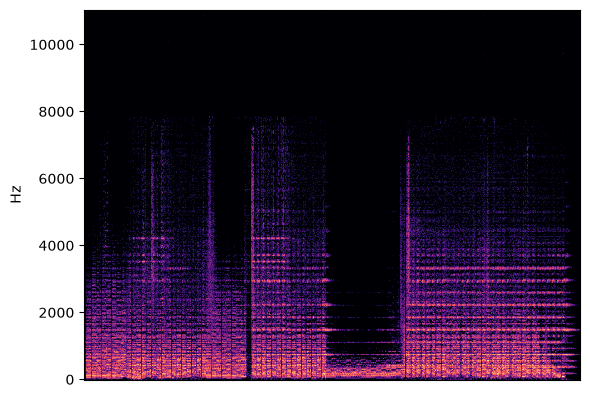

In [ ]:
D = lb.amplitude_to_db(np.abs(lb.stft(y_harm)), ref=np.max)
lb.display.specshow(D, y_axis='hz')

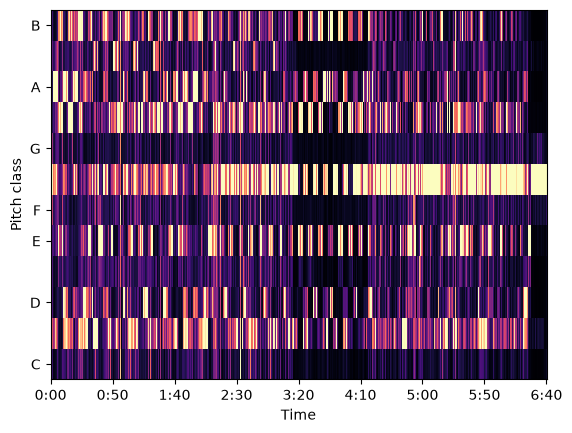

In [ ]:
chromagram = lb.feature.chroma_cqt(y=y_harm, sr=sr)
lb.display.specshow(chromagram, y_axis='chroma', x_axis='time')

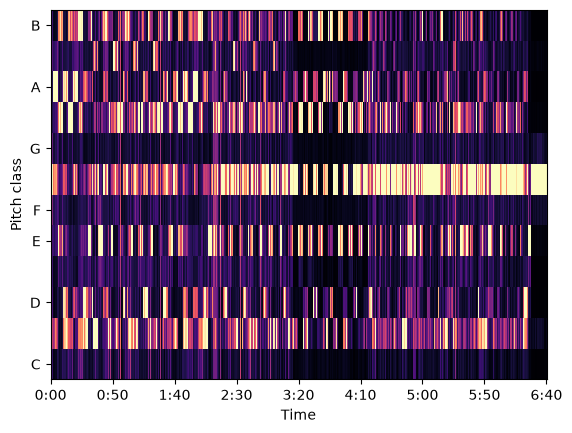

In [ ]:
chroma_filter = np.minimum(chromagram,
                           lb.decompose.nn_filter(chromagram,
                                                       aggregate=np.median,
                                                       metric='cosine'))
lb.display.specshow(chroma_filter, y_axis='chroma', x_axis='time')

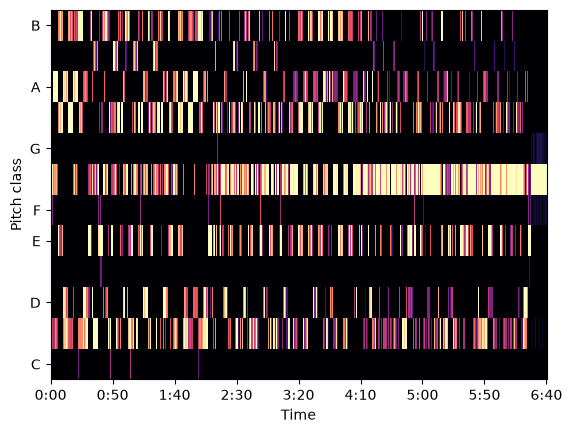

In [ ]:
chroma_smooth = np.zeros_like(chroma_filter)
top3_idx = np.argpartition(chroma_filter, -3, axis=0)[-3:, :]
cols = np.arange(chroma_filter.shape[1])
chroma_smooth[top3_idx, cols] = chroma_filter[top3_idx, cols]
lb.display.specshow(chroma_smooth, y_axis='chroma', x_axis='time')

In [ ]:
for i in range(0, len(labels), 4):
    print(', '.join(labels[i:i+4]))

C:maj, C#:maj, D:maj, D#:maj
E:maj, F:maj, F#:maj, G:maj
G#:maj, A:maj, A#:maj, B:maj
C:maj7, C#:maj7, D:maj7, D#:maj7
E:maj7, F:maj7, F#:maj7, G:maj7
G#:maj7, A:maj7, A#:maj7, B:maj7
C:min, C#:min, D:min, D#:min
E:min, F:min, F#:min, G:min
G#:min, A:min, A#:min, B:min
C:min7, C#:min7, D:min7, D#:min7
E:min7, F:min7, F#:min7, G:min7
G#:min7, A:min7, A#:min7, B:min7
C:normal7, C#:normal7, D:normal7, D#:normal7
E:normal7, F:normal7, F#:normal7, G:normal7
G#:normal7, A:normal7, A#:normal7, B:normal7
C:min9, C#:min9, D:min9, D#:min9
E:min9, F:min9, F#:min9, G:min9
G#:min9, A:min9, A#:min9, B:min9
C:dim, C#:dim, D:dim, D#:dim
E:dim, F:dim, F#:dim, G:dim
G#:dim, A:dim, A#:dim, B:dim
N


# Probabilities

In [ ]:
probs = (weights.dot(chroma_smooth))
print(probs)
path

[[0.26727565 0.25195746 0.24714591 ... 0.02506126 0.04409759 0.15622152]
 [0.21933659 0.21018652 0.20985858 ... 0.03146293 0.03701615 0.19882601]
 [0.33333333 0.33333333 0.33333333 ... 0.33333333 0.33333333 0.30265949]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.26727565 0.25195746 0.24714591 ... 0.         0.         0.15622152]
 [0.20498639 0.19886933 0.19758446 ... 0.09746438 0.10361177 0.16442676]]


testing the midi extraction

In [ ]:
from midi import export_chords_to_midi

result = export_chords_to_midi(
    'data/separated/neverender/other.wav',
    'output.mid',
    key=('F#', 'minor'),
    key_bias=True,
    keep_top=3,
    min_duration=0.15,
    bpm=120,
)

print(result['events'][:5])

Allowed chords for F# minor: ['F#:min', 'G#:dim', 'A:maj', 'B:min', 'C#:min', 'D:maj', 'E:maj']


NameError: name 'CHORD_INTERVALS' is not defined

## Percussion

In [ ]:
y_perc

array([1.7160213e-08, 4.7290891e-09, 1.3664436e-09, ..., 7.2535658e-15,
       1.4799959e-14, 9.5320760e-15], shape=(3785440,), dtype=float32)

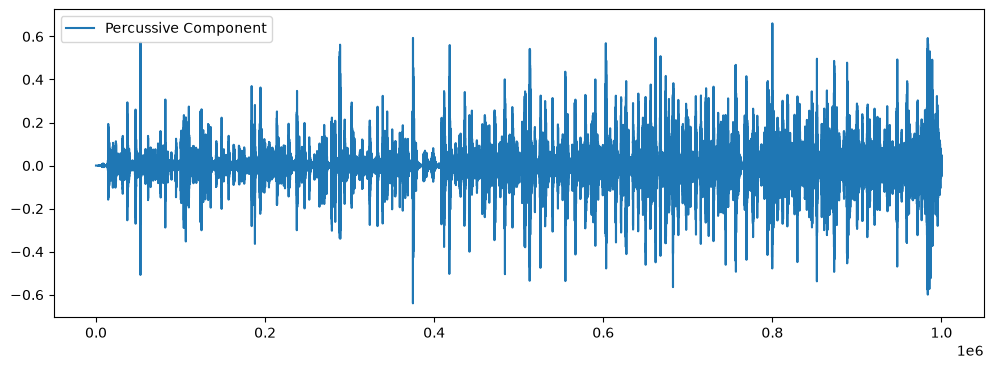

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_perc[0:1000000], label='Percussive Component')
plt.legend()
plt.show()

In [ ]:
tempo, beats_static = lb.beat.beat_track(y=y, sr=sr, units='time', trim=False)

print(f"Tempo estimate: {tempo[0]:.2f} BPM")

Tempo estimate: 152.00 BPM
